In [15]:
import pandas as pd
from pathlib import Path

root = Path("../data/raw/mrl")
df = pd.read_csv("../results/mrl_metadata.csv")

print(df["split"].value_counts())
print()
print(pd.crosstab(df["split"], df["ojo"]))
df.head()

split
train    67269
test     11041
val       6588
Name: count, dtype: int64

ojo        0      1
split              
test    4890   6151
train  33899  33370
val     3157   3431


,ruta,archivo,sujeto,genero,lentes,ojo,reflejos,luz,sensor,split_original,split
0,train\awake\s0001_01842_0_0_1_0_0_01.png,s0001_01842_0_0_1_0_0_01.png,s0001,0,0,1,0,0,1,train,train
1,train\awake\s0001_01843_0_0_1_0_0_01.png,s0001_01843_0_0_1_0_0_01.png,s0001,0,0,1,0,0,1,train,train
2,train\awake\s0001_01845_0_0_1_0_0_01.png,s0001_01845_0_0_1_0_0_01.png,s0001,0,0,1,0,0,1,train,train
3,train\awake\s0001_01848_0_0_1_0_0_01.png,s0001_01848_0_0_1_0_0_01.png,s0001,0,0,1,0,0,1,train,train
4,train\awake\s0001_01852_0_0_1_0_0_01.png,s0001_01852_0_0_1_0_0_01.png,s0001,0,0,1,0,0,1,train,train


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class OjosDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        img = Image.open(self.root_dir / fila["ruta"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        etiqueta = fila["ojo"]  # 1 = abierto, 0 = cerrado
        return img, etiqueta

# Normalización estándar de ImageNet (la usa el modelo preentrenado)
media = [0.485, 0.456, 0.406]
desv = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

train_ds = OjosDataset(df[df.split == "train"], root, train_tf)
val_ds   = OjosDataset(df[df.split == "val"], root, eval_tf)
test_ds  = OjosDataset(df[df.split == "test"], root, eval_tf)

print("train:", len(train_ds), "| val:", len(val_ds), "| test:", len(test_ds))

train: 67269 | val: 6588 | test: 11041


In [16]:
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Prueba rápida: traer un solo lote
imgs, labels = next(iter(train_loader))
print("Forma del lote de imágenes:", imgs.shape)
print("Forma de etiquetas:", labels.shape)
print("Etiquetas de ejemplo:", labels[:10])

Forma del lote de imágenes: torch.Size([64, 3, 224, 224])
Forma de etiquetas: torch.Size([64])
Etiquetas de ejemplo: tensor([1, 0, 0, 0, 1, 0, 0, 0, 1, 1])


In [17]:
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

modelo = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Congelar las capas convolucionales (extractor de características)
for parametro in modelo.features.parameters():
    parametro.requires_grad = False

# Reemplazar el clasificador final: de 1000 clases (ImageNet) a 1 salida (binaria)
modelo.classifier[1] = nn.Linear(modelo.last_channel, 1)

modelo = modelo.to(device)
print(modelo.classifier)

Usando: cuda
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [21]:
import torch.optim as optim
import time

criterio = nn.BCEWithLogitsLoss()
optimizador = optim.Adam(modelo.classifier.parameters(), lr=1e-3)

modelo.train()
inicio = time.time()

for i, (imgs, labels) in enumerate(train_loader):
    imgs = imgs.to(device)
    labels = labels.float().unsqueeze(1).to(device)

    optimizador.zero_grad()
    salidas = modelo(imgs)
    perdida = criterio(salidas, labels)
    perdida.backward()
    optimizador.step()

    if i == 0:
        print(f"Lote 1 | Pérdida: {perdida.item():.4f}")
    if i >= 4:   # solo 5 lotes de prueba, no la época completa
        break

print(f"5 lotes procesados en {time.time() - inicio:.1f} segundos")

Lote 1 | Pérdida: 0.7091
5 lotes procesados en 5.3 segundos


In [22]:
from sklearn.metrics import accuracy_score

def entrenar_una_epoca(modelo, loader, criterio, optimizador, device):
    modelo.train()
    perdida_total = 0.0
    preds_todas, labels_todas = [], []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels_f = labels.float().unsqueeze(1).to(device)

        optimizador.zero_grad()
        salidas = modelo(imgs)
        perdida = criterio(salidas, labels_f)
        perdida.backward()
        optimizador.step()

        perdida_total += perdida.item() * imgs.size(0)
        preds = (torch.sigmoid(salidas) > 0.5).int().cpu().flatten()
        preds_todas.extend(preds.tolist())
        labels_todas.extend(labels.tolist())

    perdida_media = perdida_total / len(loader.dataset)
    exactitud = accuracy_score(labels_todas, preds_todas)
    return perdida_media, exactitud


def evaluar(modelo, loader, criterio, device):
    modelo.eval()
    perdida_total = 0.0
    preds_todas, labels_todas = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels_f = labels.float().unsqueeze(1).to(device)

            salidas = modelo(imgs)
            perdida = criterio(salidas, labels_f)

            perdida_total += perdida.item() * imgs.size(0)
            preds = (torch.sigmoid(salidas) > 0.5).int().cpu().flatten()
            preds_todas.extend(preds.tolist())
            labels_todas.extend(labels.tolist())

    perdida_media = perdida_total / len(loader.dataset)
    exactitud = accuracy_score(labels_todas, preds_todas)
    return perdida_media, exactitud

In [26]:
import copy

# Reiniciar modelo desde los pesos preentrenados
modelo = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
for parametro in modelo.features.parameters():
    parametro.requires_grad = False
modelo.classifier[1] = nn.Linear(modelo.last_channel, 1)
modelo = modelo.to(device)

criterio = nn.BCEWithLogitsLoss()
optimizador = optim.Adam(modelo.classifier.parameters(), lr=1e-3)

N_EPOCAS = 5
mejor_val_exactitud = 0.0
mejor_pesos = None
historial = []

Path("../models").mkdir(exist_ok=True)

for epoca in range(1, N_EPOCAS + 1):
    inicio = time.time()

    train_perdida, train_exactitud = entrenar_una_epoca(modelo, train_loader, criterio, optimizador, device)
    val_perdida, val_exactitud = evaluar(modelo, val_loader, criterio, device)

    duracion = time.time() - inicio
    historial.append({
        "epoca": epoca,
        "train_perdida": train_perdida, "train_exactitud": train_exactitud,
        "val_perdida": val_perdida, "val_exactitud": val_exactitud,
        "duracion_seg": duracion,
    })

    print(f"Época {epoca}/{N_EPOCAS} | "
          f"train_perdida={train_perdida:.4f} train_acc={train_exactitud:.4f} | "
          f"val_perdida={val_perdida:.4f} val_acc={val_exactitud:.4f} | "
          f"{duracion:.1f}s")

    if val_exactitud > mejor_val_exactitud:
        mejor_val_exactitud = val_exactitud
        mejor_pesos = copy.deepcopy(modelo.state_dict())
        torch.save(mejor_pesos, "../models/mobilenetv2_ojos_mejor.pth")
        print(f"  → Nuevo mejor modelo guardado (val_acc={val_exactitud:.4f})")

print("\nEntrenamiento terminado. Mejor exactitud en validación:", mejor_val_exactitud)

Época 1/5 | train_perdida=0.2419 train_acc=0.9073 | val_perdida=0.1978 val_acc=0.9281 | 1142.0s
  → Nuevo mejor modelo guardado (val_acc=0.9281)
Época 2/5 | train_perdida=0.1962 train_acc=0.9242 | val_perdida=0.1949 val_acc=0.9268 | 1024.5s
Época 3/5 | train_perdida=0.1911 train_acc=0.9270 | val_perdida=0.2093 val_acc=0.9252 | 812.7s
Época 4/5 | train_perdida=0.1933 train_acc=0.9264 | val_perdida=0.1887 val_acc=0.9299 | 845.0s
  → Nuevo mejor modelo guardado (val_acc=0.9299)
Época 5/5 | train_perdida=0.1910 train_acc=0.9265 | val_perdida=0.2063 val_acc=0.9261 | 800.7s

Entrenamiento terminado. Mejor exactitud en validación: 0.9298724954462659


In [27]:
hist_df = pd.DataFrame(historial)
hist_df.to_csv("../results/historial_entrenamiento.csv", index=False)

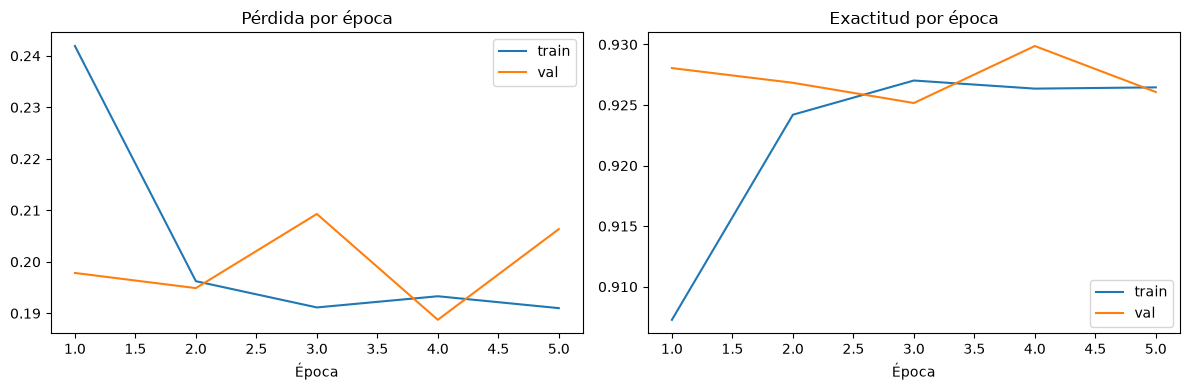

In [28]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["epoca"], hist_df["train_perdida"], label="train")
axes[0].plot(hist_df["epoca"], hist_df["val_perdida"], label="val")
axes[0].set_title("Pérdida por época")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(hist_df["epoca"], hist_df["train_exactitud"], label="train")
axes[1].plot(hist_df["epoca"], hist_df["val_exactitud"], label="val")
axes[1].set_title("Exactitud por época")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/curvas_entrenamiento.png", dpi=150)
plt.show()

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

modelo.load_state_dict(torch.load("../models/mobilenetv2_ojos_mejor.pth"))
modelo.eval()

preds_todas, labels_todas, probas_todas = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        salidas = modelo(imgs)
        probas = torch.sigmoid(salidas).cpu().flatten()
        preds = (probas > 0.5).int()

        preds_todas.extend(preds.tolist())
        probas_todas.extend(probas.tolist())
        labels_todas.extend(labels.tolist())

print("Exactitud en test:", accuracy_score(labels_todas, preds_todas))
print("AUC-ROC en test:", roc_auc_score(labels_todas, probas_todas))
print()
print(classification_report(labels_todas, preds_todas, target_names=["cerrado", "abierto"]))
print()
print("Matriz de confusión:")
print(confusion_matrix(labels_todas, preds_todas))

Exactitud en test: 0.9159496422425505
AUC-ROC en test: 0.9880689923895528

              precision    recall  f1-score   support

     cerrado       0.85      0.99      0.91      4890
     abierto       0.99      0.86      0.92      6151

    accuracy                           0.92     11041
   macro avg       0.92      0.92      0.92     11041
weighted avg       0.93      0.92      0.92     11041


Matriz de confusión:
[[4837   53]
 [ 875 5276]]


In [30]:
modelo.eval()
entrada_ejemplo = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    modelo,
    entrada_ejemplo,
    "../models/mobilenetv2_ojos.onnx",
    input_names=["entrada"],
    output_names=["salida"],
    dynamic_axes={"entrada": {0: "batch"}, "salida": {0: "batch"}},
    opset_version=17,
    dynamo=False,
)
print("Modelo exportado a ../models/mobilenetv2_ojos.onnx")

C:\Users\FIORELLA\AppData\Local\Temp\ipykernel_34824\2680117911.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Modelo exportado a ../models/mobilenetv2_ojos.onnx


In [31]:
import onnxruntime as ort
import numpy as np

# Cargar el modelo ONNX
sesion = ort.InferenceSession("../models/mobilenetv2_ojos.onnx", providers=["CPUExecutionProvider"])
print("Proveedor usado:", sesion.get_providers())
print("Entrada esperada:", sesion.get_inputs()[0].name, sesion.get_inputs()[0].shape)

# Tomar un lote real de test para comparar
imgs, labels = next(iter(test_loader))

# Predicción con PyTorch (el modelo original)
modelo.eval()
with torch.no_grad():
    salida_pytorch = modelo(imgs.to(device))
    probas_pytorch = torch.sigmoid(salida_pytorch).cpu().numpy().flatten()

# Predicción con ONNX Runtime
entradas_onnx = {sesion.get_inputs()[0].name: imgs.numpy()}
salida_onnx = sesion.run(None, entradas_onnx)[0]
probas_onnx = 1 / (1 + np.exp(-salida_onnx.flatten()))  # sigmoid manual

# Comparar
diferencia_maxima = np.abs(probas_pytorch - probas_onnx).max()
print(f"\nDiferencia máxima entre PyTorch y ONNX: {diferencia_maxima:.6f}")
print("Primeras 5 probabilidades PyTorch:", probas_pytorch[:5].round(4))
print("Primeras 5 probabilidades ONNX:   ", probas_onnx[:5].round(4))

Proveedor usado: ['CPUExecutionProvider']
Entrada esperada: entrada ['batch', 3, 224, 224]

Diferencia máxima entre PyTorch y ONNX: 0.004980
Primeras 5 probabilidades PyTorch: [0.4573 0.9275 0.7316 0.4092 0.9545]
Primeras 5 probabilidades ONNX:    [0.4559 0.9272 0.7315 0.4089 0.9539]


In [32]:
preds_pytorch_todas, preds_onnx_todas = [], []
diferencias = []

modelo.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        salida_pt = modelo(imgs.to(device))
        probas_pt = torch.sigmoid(salida_pt).cpu().numpy().flatten()

        entradas_onnx = {sesion.get_inputs()[0].name: imgs.numpy()}
        salida_onnx = sesion.run(None, entradas_onnx)[0]
        probas_onnx = 1 / (1 + np.exp(-salida_onnx.flatten()))

        preds_pytorch_todas.extend((probas_pt > 0.5).astype(int).tolist())
        preds_onnx_todas.extend((probas_onnx > 0.5).astype(int).tolist())
        diferencias.extend(np.abs(probas_pt - probas_onnx).tolist())

diferencias = np.array(diferencias)
preds_pytorch_todas = np.array(preds_pytorch_todas)
preds_onnx_todas = np.array(preds_onnx_todas)

print("Diferencia promedio:", diferencias.mean().round(6))
print("Diferencia máxima:", diferencias.max().round(6))
print("Predicciones que coinciden entre PyTorch y ONNX:",
      (preds_pytorch_todas == preds_onnx_todas).sum(), "de", len(preds_pytorch_todas))
print("Porcentaje de coincidencia:", (preds_pytorch_todas == preds_onnx_todas).mean() * 100, "%")

Diferencia promedio: 0.000623
Diferencia máxima: 0.007321
Predicciones que coinciden entre PyTorch y ONNX: 11038 de 11041
Porcentaje de coincidencia: 99.97282854813876 %


In [33]:
print(df_test["lentes"].dtype)
print(df_test["lentes"].unique())

NameError: name 'df_test' is not defined

In [34]:
print("Exactitud CON lentes:", df_test[df_test["lentes"] == 1]["correcto"].mean().round(3))
print("Exactitud SIN lentes:", df_test[df_test["lentes"] == 0]["correcto"].mean().round(3))
print()
print("Cantidad de imágenes con lentes en test:", (df_test["lentes"] == 1).sum())
print("Cantidad de imágenes sin lentes en test:", (df_test["lentes"] == 0).sum())

NameError: name 'df_test' is not defined

In [22]:
# Cargar el mejor modelo de la Etapa 1 (capas congeladas)
modelo_etapa2 = models.mobilenet_v2(weights=None)  # arquitectura vacía
modelo_etapa2.classifier[1] = nn.Linear(modelo_etapa2.last_channel, 1)
modelo_etapa2.load_state_dict(torch.load("../models/mobilenetv2_ojos_mejor.pth"))
modelo_etapa2 = modelo_etapa2.to(device)

print("Modelo de Etapa 1 cargado correctamente.")

Modelo de Etapa 1 cargado correctamente.


In [23]:
# Ver cuántos bloques tiene 'features', para decidir cuántos descongelar
print("Total de bloques en features:", len(modelo_etapa2.features))

# Congelar TODO de nuevo, como punto de partida
for parametro in modelo_etapa2.parameters():
    parametro.requires_grad = False

# Descongelar solo los últimos 3 bloques + el clasificador
N_BLOQUES_DESCONGELAR = 3
for bloque in modelo_etapa2.features[-N_BLOQUES_DESCONGELAR:]:
    for parametro in bloque.parameters():
        parametro.requires_grad = True

for parametro in modelo_etapa2.classifier.parameters():
    parametro.requires_grad = True

# Verificar cuántos parámetros quedaron entrenables
entrenables = sum(p.numel() for p in modelo_etapa2.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo_etapa2.parameters())
print(f"Parámetros entrenables: {entrenables:,} de {total:,} ({100*entrenables/total:.1f}%)")

Total de bloques en features: 19
Parámetros entrenables: 1,207,361 de 2,225,153 (54.3%)


In [24]:
criterio = nn.BCEWithLogitsLoss()
optimizador_ft = optim.Adam(
    filter(lambda p: p.requires_grad, modelo_etapa2.parameters()),
    lr=1e-5   # 100 veces menor que en la Etapa 1
)

N_EPOCAS_FT = 5
mejor_val_exactitud_ft = 0.0
historial_ft = []

for epoca in range(1, N_EPOCAS_FT + 1):
    inicio = time.time()

    train_perdida, train_exactitud = entrenar_una_epoca(modelo_etapa2, train_loader, criterio, optimizador_ft, device)
    val_perdida, val_exactitud = evaluar(modelo_etapa2, val_loader, criterio, device)

    duracion = time.time() - inicio
    historial_ft.append({
        "epoca": epoca,
        "train_perdida": train_perdida, "train_exactitud": train_exactitud,
        "val_perdida": val_perdida, "val_exactitud": val_exactitud,
        "duracion_seg": duracion,
    })

    print(f"[Fine-tuning] Época {epoca}/{N_EPOCAS_FT} | "
          f"train_acc={train_exactitud:.4f} | val_acc={val_exactitud:.4f} | {duracion:.1f}s")

    if val_exactitud > mejor_val_exactitud_ft:
        mejor_val_exactitud_ft = val_exactitud
        torch.save(modelo_etapa2.state_dict(), "../models/mobilenetv2_ojos_finetuned.pth")
        print(f"  → Nuevo mejor modelo (fine-tuned) guardado (val_acc={val_exactitud:.4f})")

print("\nFine-tuning terminado. Mejor exactitud en validación:", mejor_val_exactitud_ft)

[Fine-tuning] Época 1/5 | train_acc=0.9495 | val_acc=0.9464 | 861.8s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9464)
[Fine-tuning] Época 2/5 | train_acc=0.9625 | val_acc=0.9529 | 302.6s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9529)
[Fine-tuning] Época 3/5 | train_acc=0.9665 | val_acc=0.9531 | 459.7s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9531)
[Fine-tuning] Época 4/5 | train_acc=0.9699 | val_acc=0.9589 | 414.8s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9589)
[Fine-tuning] Época 5/5 | train_acc=0.9717 | val_acc=0.9570 | 273.7s

Fine-tuning terminado. Mejor exactitud en validación: 0.9588646023072253


In [25]:
def evaluar_en_test(modelo, test_loader, device):
    modelo.eval()
    preds, labels_todas, probas = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            salidas = modelo(imgs.to(device))
            p = torch.sigmoid(salidas).cpu().flatten()
            preds.extend((p > 0.5).int().tolist())
            probas.extend(p.tolist())
            labels_todas.extend(labels.tolist())
    return labels_todas, preds, probas

# Modelo Etapa 1 (el que ya teníamos)
modelo.load_state_dict(torch.load("../models/mobilenetv2_ojos_mejor.pth"))
labels_e1, preds_e1, probas_e1 = evaluar_en_test(modelo, test_loader, device)

# Modelo Etapa 2 (fine-tuned)
modelo_etapa2.load_state_dict(torch.load("../models/mobilenetv2_ojos_finetuned.pth"))
labels_e2, preds_e2, probas_e2 = evaluar_en_test(modelo_etapa2, test_loader, device)

print("=== ETAPA 1 (solo clasificador) ===")
print("Exactitud:", accuracy_score(labels_e1, preds_e1))
print("AUC-ROC:", roc_auc_score(labels_e1, probas_e1))
print()
print("=== ETAPA 2 (fine-tuning) ===")
print("Exactitud:", accuracy_score(labels_e2, preds_e2))
print("AUC-ROC:", roc_auc_score(labels_e2, probas_e2))
print()
print("=== Reporte detallado, Etapa 2 ===")
print(classification_report(labels_e2, preds_e2, target_names=["cerrado", "abierto"]))
print("Matriz de confusión (Etapa 2):")
print(confusion_matrix(labels_e2, preds_e2))

=== ETAPA 1 (solo clasificador) ===
Exactitud: 0.911421066932343
AUC-ROC: 0.9867653321869952

=== ETAPA 2 (fine-tuning) ===
Exactitud: 0.9600579657639706
AUC-ROC: 0.996775774900186

=== Reporte detallado, Etapa 2 ===
              precision    recall  f1-score   support

     cerrado       0.92      0.99      0.96      4890
     abierto       1.00      0.93      0.96      6151

    accuracy                           0.96     11041
   macro avg       0.96      0.96      0.96     11041
weighted avg       0.96      0.96      0.96     11041

Matriz de confusión (Etapa 2):
[[4863   27]
 [ 414 5737]]


In [26]:
hist_ft_df = pd.DataFrame(historial_ft)
hist_ft_df.to_csv("../results/historial_finetuning_ojos.csv", index=False)

comparacion = pd.DataFrame({
    "etapa": ["Etapa 1 (clasificador)", "Etapa 2 (fine-tuning)"],
    "exactitud_test": [accuracy_score(labels_e1, preds_e1), accuracy_score(labels_e2, preds_e2)],
    "auc_roc_test": [roc_auc_score(labels_e1, probas_e1), roc_auc_score(labels_e2, probas_e2)],
})
comparacion.to_csv("../results/comparacion_ojos_etapas.csv", index=False)
print(comparacion)

                    etapa  exactitud_test  auc_roc_test
0  Etapa 1 (clasificador)        0.911421      0.986765
1   Etapa 2 (fine-tuning)        0.960058      0.996776


In [27]:
modelo_etapa2.eval()
entrada_ejemplo = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    modelo_etapa2,
    entrada_ejemplo,
    "../models/mobilenetv2_ojos.onnx",   # sobrescribe el ONNX anterior (Etapa 1) con el nuevo (Etapa 2)
    input_names=["entrada"],
    output_names=["salida"],
    dynamic_axes={"entrada": {0: "batch"}, "salida": {0: "batch"}},
    opset_version=17,
    dynamo=False,
)
print("Modelo fine-tuned exportado a ../models/mobilenetv2_ojos.onnx")

C:\Users\FIORELLA\AppData\Local\Temp\ipykernel_10164\1869534067.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Modelo fine-tuned exportado a ../models/mobilenetv2_ojos.onnx


In [28]:
sesion = ort.InferenceSession("../models/mobilenetv2_ojos.onnx", providers=["CPUExecutionProvider"])
nombre_entrada = sesion.get_inputs()[0].name

imgs, labels = next(iter(test_loader))
modelo_etapa2.eval()
with torch.no_grad():
    salida_pt = modelo_etapa2(imgs.to(device))
    probas_pt = torch.sigmoid(salida_pt).cpu().numpy().flatten()

entradas_onnx = {nombre_entrada: imgs.numpy()}
salida_onnx = sesion.run(None, entradas_onnx)[0]
probas_onnx = 1 / (1 + np.exp(-salida_onnx.flatten()))

print("Diferencia máxima:", np.abs(probas_pt - probas_onnx).max().round(6))

Diferencia máxima: 0.003366


In [29]:
import cv2
from PIL import Image

class MitigarBrechaDominio:
    """Convierte a escala de grises, aumenta el brillo y aplica CLAHE,
    luego replica a 3 canales para mantener compatibilidad con MobileNetV2."""
    def __init__(self, aumento_brillo=30, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.aumento_brillo = aumento_brillo
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)  # PIL -> numpy (RGB)
        gris = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

        # Aumento de brillo (suma directa, saturando en 255)
        gris = cv2.convertScaleAbs(gris, alpha=1.0, beta=self.aumento_brillo)

        # CLAHE: ecualización adaptativa de contraste
        gris_clahe = self.clahe.apply(gris)

        # Replicar a 3 canales para la entrada del modelo
        img_3canales = cv2.cvtColor(gris_clahe, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_3canales)

print("Transformación de mitigación de dominio definida.")

Transformación de mitigación de dominio definida.


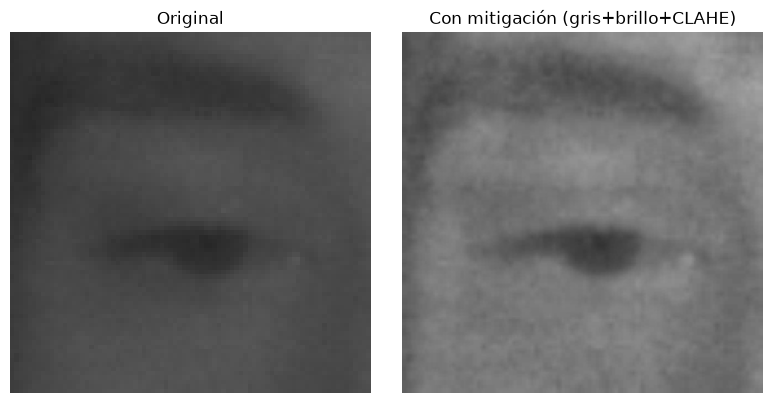

In [30]:
train_tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    MitigarBrechaDominio(),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

eval_tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    MitigarBrechaDominio(),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

train_ds_v2 = OjosDataset(df[df.split == "train"], root, train_tf_v2)
val_ds_v2   = OjosDataset(df[df.split == "val"], root, eval_tf_v2)
test_ds_v2  = OjosDataset(df[df.split == "test"], root, eval_tf_v2)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=64, shuffle=True, num_workers=0)
val_loader_v2   = DataLoader(val_ds_v2, batch_size=64, shuffle=False, num_workers=0)
test_loader_v2  = DataLoader(test_ds_v2, batch_size=64, shuffle=False, num_workers=0)

# Verificación visual rápida: comparar antes/después de la transformación
img_original = Image.open(root / df[df.split=="train"].iloc[0]["ruta"]).convert("RGB")
img_transformada = MitigarBrechaDominio()(transforms.Resize((224,224))(img_original))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(img_transformada); axes[1].set_title("Con mitigación (gris+brillo+CLAHE)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [31]:
modelo_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
for parametro in modelo_v2.features.parameters():
    parametro.requires_grad = False
modelo_v2.classifier[1] = nn.Linear(modelo_v2.last_channel, 1)
modelo_v2 = modelo_v2.to(device)

criterio = nn.BCEWithLogitsLoss()
optimizador_v2 = optim.Adam(modelo_v2.classifier.parameters(), lr=1e-3)

N_EPOCAS = 5
mejor_val_exactitud_v2 = 0.0
historial_v2 = []

for epoca in range(1, N_EPOCAS + 1):
    inicio = time.time()
    train_perdida, train_exactitud = entrenar_una_epoca(modelo_v2, train_loader_v2, criterio, optimizador_v2, device)
    val_perdida, val_exactitud = evaluar(modelo_v2, val_loader_v2, criterio, device)
    duracion = time.time() - inicio

    historial_v2.append({"epoca": epoca, "train_perdida": train_perdida, "train_exactitud": train_exactitud,
                          "val_perdida": val_perdida, "val_exactitud": val_exactitud, "duracion_seg": duracion})
    print(f"[v2-Etapa1] Época {epoca}/{N_EPOCAS} | train_acc={train_exactitud:.4f} | val_acc={val_exactitud:.4f} | {duracion:.1f}s")

    if val_exactitud > mejor_val_exactitud_v2:
        mejor_val_exactitud_v2 = val_exactitud
        torch.save(modelo_v2.state_dict(), "../models/mobilenetv2_ojos_v2_etapa1.pth")
        print(f"  → Nuevo mejor modelo guardado (val_acc={val_exactitud:.4f})")

print("\nEtapa 1 (v2) terminada. Mejor val_acc:", mejor_val_exactitud_v2)

[v2-Etapa1] Época 1/5 | train_acc=0.9090 | val_acc=0.9361 | 1078.5s
  → Nuevo mejor modelo guardado (val_acc=0.9361)
[v2-Etapa1] Época 2/5 | train_acc=0.9207 | val_acc=0.9369 | 1032.8s
  → Nuevo mejor modelo guardado (val_acc=0.9369)
[v2-Etapa1] Época 3/5 | train_acc=0.9257 | val_acc=0.9396 | 679.8s
  → Nuevo mejor modelo guardado (val_acc=0.9396)
[v2-Etapa1] Época 4/5 | train_acc=0.9227 | val_acc=0.9381 | 861.5s
[v2-Etapa1] Época 5/5 | train_acc=0.9219 | val_acc=0.9373 | 387.3s

Etapa 1 (v2) terminada. Mejor val_acc: 0.9395871281117183


In [6]:
try:
    print(train_loader_v2)
    print(modelo_v2)
    print("Todo en memoria, puedes continuar directo al 15D.")
except NameError as e:
    print("Falta recargar el entorno:", e)

Falta recargar el entorno: name 'train_loader_v2' is not defined


In [7]:
import pandas as pd
from pathlib import Path

root = Path("../data/raw/mrl")
df = pd.read_csv("../results/mrl_metadata.csv")

In [8]:
import cv2
from PIL import Image

class MitigarBrechaDominio:
    def __init__(self, aumento_brillo=30, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.aumento_brillo = aumento_brillo
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        gris = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        gris = cv2.convertScaleAbs(gris, alpha=1.0, beta=self.aumento_brillo)
        gris_clahe = self.clahe.apply(gris)
        img_3canales = cv2.cvtColor(gris_clahe, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_3canales)

In [18]:
from torch.utils.data import DataLoader
from torchvision import transforms
train_tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    MitigarBrechaDominio(),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

eval_tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    MitigarBrechaDominio(),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

train_ds_v2 = OjosDataset(df[df.split == "train"], root, train_tf_v2)
val_ds_v2   = OjosDataset(df[df.split == "val"], root, eval_tf_v2)
test_ds_v2  = OjosDataset(df[df.split == "test"], root, eval_tf_v2)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=64, shuffle=True, num_workers=0)
val_loader_v2   = DataLoader(val_ds_v2, batch_size=64, shuffle=False, num_workers=0)
test_loader_v2  = DataLoader(test_ds_v2, batch_size=64, shuffle=False, num_workers=0)

print("Loaders v2 reconstruidos.")

Loaders v2 reconstruidos.


In [35]:
try:
    print(train_loader_v2)
    print(len(train_loader_v2.dataset), "imágenes en train_loader_v2")
    print("Todo en memoria, puedes continuar directo al 15D.")
except NameError as e:
    print("Falta recargar el entorno:", e)

67269 imágenes en train_loader_v2
Todo en memoria, puedes continuar directo al 15D.


In [36]:
modelo_v2_ft = models.mobilenet_v2(weights=None)
modelo_v2_ft.classifier[1] = nn.Linear(modelo_v2_ft.last_channel, 1)
modelo_v2_ft.load_state_dict(torch.load("../models/mobilenetv2_ojos_v2_etapa1.pth"))
modelo_v2_ft = modelo_v2_ft.to(device)

for parametro in modelo_v2_ft.parameters():
    parametro.requires_grad = False
for bloque in modelo_v2_ft.features[-3:]:
    for parametro in bloque.parameters():
        parametro.requires_grad = True
for parametro in modelo_v2_ft.classifier.parameters():
    parametro.requires_grad = True

criterio = nn.BCEWithLogitsLoss()
optimizador_v2_ft = optim.Adam(filter(lambda p: p.requires_grad, modelo_v2_ft.parameters()), lr=1e-5)

N_EPOCAS = 5
mejor_val_exactitud_v2_ft = 0.0
historial_v2_ft = []

for epoca in range(1, N_EPOCAS + 1):
    inicio = time.time()
    train_perdida, train_exactitud = entrenar_una_epoca(modelo_v2_ft, train_loader_v2, criterio, optimizador_v2_ft, device)
    val_perdida, val_exactitud = evaluar(modelo_v2_ft, val_loader_v2, criterio, device)
    duracion = time.time() - inicio

    historial_v2_ft.append({"epoca": epoca, "train_perdida": train_perdida, "train_exactitud": train_exactitud,
                             "val_perdida": val_perdida, "val_exactitud": val_exactitud, "duracion_seg": duracion})
    print(f"[v2-Etapa2] Época {epoca}/{N_EPOCAS} | train_acc={train_exactitud:.4f} | val_acc={val_exactitud:.4f} | {duracion:.1f}s")

    if val_exactitud > mejor_val_exactitud_v2_ft:
        mejor_val_exactitud_v2_ft = val_exactitud
        torch.save(modelo_v2_ft.state_dict(), "../models/mobilenetv2_ojos_v2_finetuned.pth")
        print(f"  → Nuevo mejor modelo (fine-tuned v2) guardado (val_acc={val_exactitud:.4f})")

print("\nEtapa 2 (v2) terminada. Mejor val_acc:", mejor_val_exactitud_v2_ft)
print("\nEtapa 2 (v2) terminada. Mejor val_acc:", mejor_val_exactitud_v2_ft)

[v2-Etapa2] Época 1/5 | train_acc=0.9474 | val_acc=0.9496 | 1130.3s
  → Nuevo mejor modelo (fine-tuned v2) guardado (val_acc=0.9496)
[v2-Etapa2] Época 2/5 | train_acc=0.9615 | val_acc=0.9569 | 1091.7s
  → Nuevo mejor modelo (fine-tuned v2) guardado (val_acc=0.9569)
[v2-Etapa2] Época 3/5 | train_acc=0.9656 | val_acc=0.9564 | 1451.4s
[v2-Etapa2] Época 4/5 | train_acc=0.9688 | val_acc=0.9570 | 1150.5s
  → Nuevo mejor modelo (fine-tuned v2) guardado (val_acc=0.9570)
[v2-Etapa2] Época 5/5 | train_acc=0.9710 | val_acc=0.9619 | 980.2s
  → Nuevo mejor modelo (fine-tuned v2) guardado (val_acc=0.9619)

Etapa 2 (v2) terminada. Mejor val_acc: 0.9619004250151791

Etapa 2 (v2) terminada. Mejor val_acc: 0.9619004250151791


In [37]:
def evaluar_en_test_completo(modelo, loader, device):
    modelo.eval()
    preds, labels_todas, probas = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            salidas = modelo(imgs.to(device))
            p = torch.sigmoid(salidas).cpu().flatten()
            preds.extend((p > 0.5).int().tolist())
            probas.extend(p.tolist())
            labels_todas.extend(labels.tolist())
    return labels_todas, preds, probas

# Modelo SIN mitigación (fine-tuned), evaluado con test_loader ORIGINAL (sin CLAHE)
modelo_etapa2 = models.mobilenet_v2(weights=None)
modelo_etapa2.classifier[1] = nn.Linear(modelo_etapa2.last_channel, 1)
modelo_etapa2.load_state_dict(torch.load("../models/mobilenetv2_ojos_finetuned.pth"))
modelo_etapa2 = modelo_etapa2.to(device)
labels_sin, preds_sin, probas_sin = evaluar_en_test_completo(modelo_etapa2, test_loader, device)

# Modelo CON mitigación (v2 fine-tuned), evaluado con test_loader_v2 (con CLAHE)
labels_con, preds_con, probas_con = evaluar_en_test_completo(modelo_v2_ft, test_loader_v2, device)

print("=== SIN mitigación de dominio (fine-tuned) ===")
print("Exactitud:", accuracy_score(labels_sin, preds_sin))
print("AUC-ROC:", roc_auc_score(labels_sin, probas_sin))
print()
print("=== CON mitigación de dominio (v2, fine-tuned) ===")
print("Exactitud:", accuracy_score(labels_con, preds_con))
print("AUC-ROC:", roc_auc_score(labels_con, probas_con))
print()
print("=== Reporte detallado, CON mitigación ===")
print(classification_report(labels_con, preds_con, target_names=["cerrado", "abierto"]))
print("Matriz de confusión (con mitigación):")
print(confusion_matrix(labels_con, preds_con))

=== SIN mitigación de dominio (fine-tuned) ===
Exactitud: 0.9600579657639706
AUC-ROC: 0.996775774900186

=== CON mitigación de dominio (v2, fine-tuned) ===
Exactitud: 0.9695679739154062
AUC-ROC: 0.9962087232727549

=== Reporte detallado, CON mitigación ===
              precision    recall  f1-score   support

     cerrado       0.94      0.99      0.97      4890
     abierto       0.99      0.95      0.97      6151

    accuracy                           0.97     11041
   macro avg       0.97      0.97      0.97     11041
weighted avg       0.97      0.97      0.97     11041

Matriz de confusión (con mitigación):
[[4839   51]
 [ 285 5866]]


In [38]:
modelo_v2_ft.eval()
entrada_ejemplo = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    modelo_v2_ft,
    entrada_ejemplo,
    "../models/mobilenetv2_ojos.onnx",   # sobrescribe con la versión definitiva (con mitigación)
    input_names=["entrada"],
    output_names=["salida"],
    dynamic_axes={"entrada": {0: "batch"}, "salida": {0: "batch"}},
    opset_version=17,
    dynamo=False,
)
print("Modelo definitivo (con mitigación) exportado a ../models/mobilenetv2_ojos.onnx")

# Guardar la comparación final para tu informe
comparacion_final = pd.DataFrame({
    "version": ["Sin mitigación (fine-tuned)", "Con mitigación CLAHE (v2, fine-tuned)"],
    "exactitud_test": [accuracy_score(labels_sin, preds_sin), accuracy_score(labels_con, preds_con)],
    "auc_roc_test": [roc_auc_score(labels_sin, probas_sin), roc_auc_score(labels_con, probas_con)],
    "recall_cerrado": [4863/4890, 4839/4890],
    "recall_abierto": [5737/6151, 5866/6151],
})
comparacion_final.to_csv("../results/comparacion_mitigacion_dominio.csv", index=False)
print(comparacion_final)

C:\Users\FIORELLA\AppData\Local\Temp\ipykernel_34824\2111696834.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Modelo definitivo (con mitigación) exportado a ../models/mobilenetv2_ojos.onnx
                                 version  exactitud_test  auc_roc_test  \
0            Sin mitigación (fine-tuned)        0.960058      0.996776   
1  Con mitigación CLAHE (v2, fine-tuned)        0.969568      0.996209   

   recall_cerrado  recall_abierto  
0        0.994479        0.932694  
1        0.989571        0.953666  


In [3]:
from pathlib import Path

imagenes = list(Path("../data/raw").rglob("*.png")) + list(Path("../data/raw").rglob("*.jpg"))

print("Cantidad encontrada:", len(imagenes))

for img in imagenes[:10]:
    print(img)

Cantidad encontrada: 90018
..\data\raw\mrl\test\awake\s0001_01846_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01847_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01849_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01850_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01855_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01870_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01876_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01879_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01882_0_0_1_0_0_01.png
..\data\raw\mrl\test\awake\s0001_01885_0_0_1_0_0_01.png


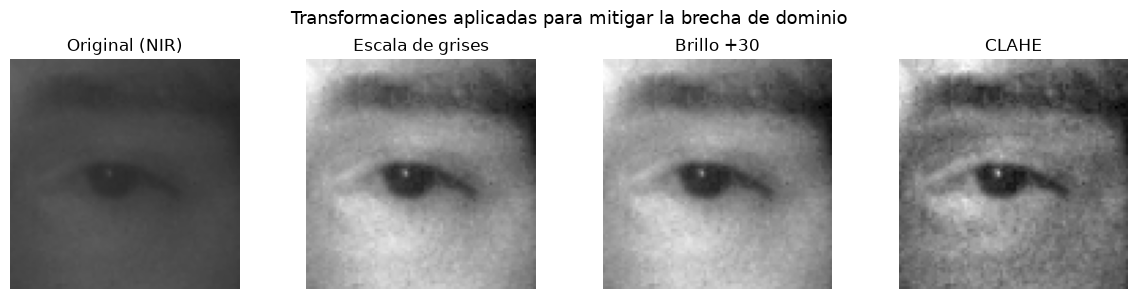

Figura guardada en: ..\results\fig_transformaciones_mrl.png


In [5]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

ruta = Path("../data/raw/mrl/test/awake/s0001_01846_0_0_1_0_0_01.png")
img = cv2.imread(str(ruta))
assert img is not None, "No se pudo cargar la imagen"

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
brillo = cv2.convertScaleAbs(gray, alpha=1, beta=30)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(brillo)

fig, axes = plt.subplots(1,4, figsize=(12,3))
imagenes = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), gray, brillo, clahe_img]
titulos = ["Original (NIR)", "Escala de grises", "Brillo +30", "CLAHE"]

for ax, imagen, titulo in zip(axes, imagenes, titulos):
    ax.imshow(imagen, cmap=None if imagen.ndim == 3 else "gray")
    ax.set_title(titulo)
    ax.axis("off")

plt.suptitle("Transformaciones aplicadas para mitigar la brecha de dominio", fontsize=13)
plt.tight_layout()

salida = Path("../results/fig_transformaciones_mrl.png")
plt.savefig(salida, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", salida)